# 0. Install Packages and import dependencies

In [3]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
!pip install -q nltk
!pip install -q gensim
!pip install -q pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 15.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# 1. Filter data

In [3]:
#Download file stored in public link inside my Drive
file_id = "1JV1042569xU3Gu0cUZOWdPjYuOp2KOlD"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_csv(url)

In [4]:
df_caffeine = df[df['title'].str.contains('caffeine', case=False)]

In [6]:
len(df_caffeine)

8

In [6]:
len(df)

806

In [7]:
def plot_articles_per_year(df):
  counts = df.groupby(['year', 'document_category']).size().unstack(fill_value=0)
  counts.rename(columns={"research": "Research", "review": "Review"}, inplace=True)
  counts.plot(kind='bar', stacked=True, figsize=(10,6))
  plt.title("Number of Research Publications on Creatine Supplementation by Year")
  plt.xlabel("Year")
  plt.ylabel("Number of Publications")
  plt.xticks(rotation=45)
  plt.legend(title="Document Type")
  plt.tight_layout()
  plt.show()


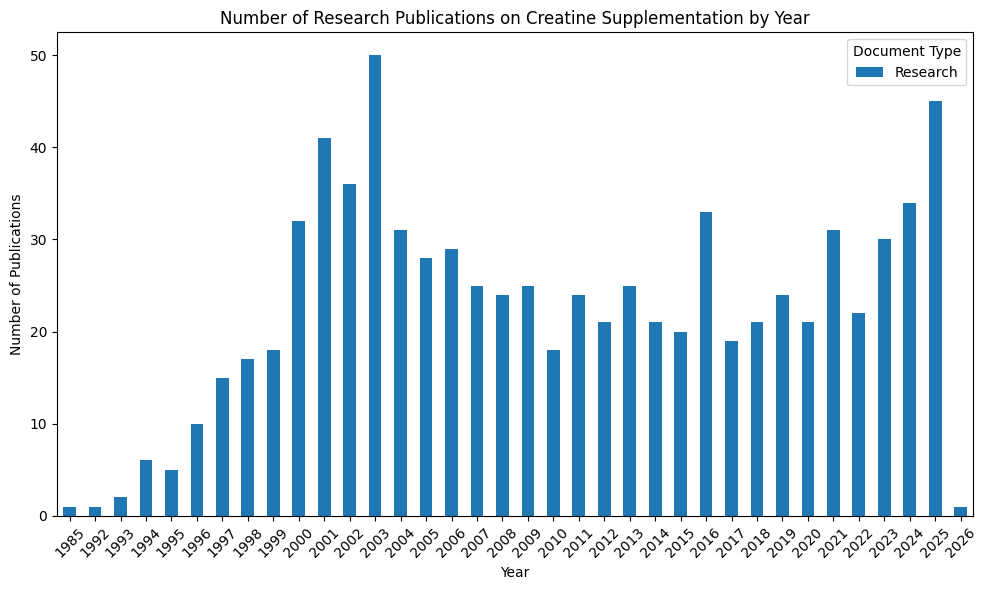

In [8]:
plot_articles_per_year(df)

In [9]:
def count_words(abstract):
    tokens = nltk.word_tokenize(abstract)
    return len(tokens)

df['word_count'] = df['raw_corpus'].apply(count_words)

average = df['word_count'].sum()/len(df['word_count'])

In [10]:
print(f"Average number of tokens: {average}")

Average number of tokens: 295.1029776674938


In [11]:
import numpy as np
import json
import glob

#Gensim
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel

#spacy
import spacy
!python -m spacy download en_core_web_md
from nltk.corpus import stopwords

#vis
import pyLDAvis
import pyLDAvis.gensim
warnings.filterwarnings("ignore", category=DeprecationWarning)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 47.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


#2. NLP Preprocessing

## 2.1 Remove stopwords

In [12]:
''' stopwords_to_remove = set(stopwords.words("english"))
#stopwords_to_remove.update(['however', 'placebo', 'trial', 'group', 'currently', 'also', 'level', 'day'])
def remove_stopwords(text):
  tokens = nltk.word_tokenize(text.lower())
  filtered_tokens = [token for token in tokens if token not in stopwords_to_remove]
  return " ".join(filtered_tokens) '''

' stopwords_to_remove = set(stopwords.words("english"))\n#stopwords_to_remove.update([\'however\', \'placebo\', \'trial\', \'group\', \'currently\', \'also\', \'level\', \'day\'])\ndef remove_stopwords(text):\n  tokens = nltk.word_tokenize(text.lower())\n  filtered_tokens = [token for token in tokens if token not in stopwords_to_remove]\n  return " ".join(filtered_tokens) '

In [13]:
test_text = "Effect of creatine however supplementation on kidney function: a systematic review and meta-analysis. Creatine monohydrate is a widely used dietary supplement with proven benefits in athletic performance and potential therapeutic applications in clinical populations. However, concerns regarding its impact on renal function persist, largely due to elevated serum creatinine levels associated with creatine intake. A comprehensive literature search was conducted in PubMed, Scopus, Web of Science, and Google Scholar for studies published between January 2000 and March 2025. Primary outcomes were serum creatinine and glomerular filtration rate (GFR). Meta-analyses were performed using a random-effects model, with subgroup analysis by supplementation duration. Twenty-one studies were included in the systematic review, and 12 studies (177 participants in the creatine group and 263 in control) were eligible for meta-analysis of serum creatinine levels. Creatine supplementation was associated with a small but statistically significant increase in serum creatinine (MD: 0.07 µmol/L; 95% CI: 0.01 to 0.12; p = 0.03). Subgroup analysis of the creatinine outcome based on follow-up duration revealed that the intervention effect was significant in studies with a follow-up of ≤ 1 week (MD = 0.12; 95% CI: 0.03 to 0.21). However, no significant effect was observed in studies with a follow-up of 1 to 12 weeks (MD = 0.04; 95% CI: - 0.09 to 0.17). The effect became significant again in studies with a follow-up of more than 12 weeks. The meta-analysis revealed a non-statistically significant differences in GFR following creatine supplementation compared to control. Creatine supplementation is associated with a modest, transient increase in serum creatinine levels, likely due to metabolic turnover rather than renal impairment. No significant changes were observed in GFR, suggesting preserved kidney function. Not applicable."

In [14]:
''' tokens = nltk.word_tokenize(test_text.lower())
filtered_tokens = [token for token in tokens if token not in stopwords_to_remove]
print(" ".join(filtered_tokens)) '''

' tokens = nltk.word_tokenize(test_text.lower())\nfiltered_tokens = [token for token in tokens if token not in stopwords_to_remove]\nprint(" ".join(filtered_tokens)) '

In [15]:
lemmatizer = spacy.load('en_core_web_sm', disable=["parser", "ner"]) #Disable ner and parser to make the model run faster
allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']
def lemmatize(text):
  text_lemma_list = [token.lemma_ for token in lemmatizer(text) if token.pos_ in allowed_postags]
  return " ".join(text_lemma_list)

#Tokenize and remove small tokens and punctuation
def gensim_words(text):
  gensim_word = gensim.utils.simple_preprocess(text, deacc=True, min_len=3)
  return gensim_word

In [16]:
#Apply all pipeline processes
def nlp_preprocessing_pipeline(text):
  return gensim_words(lemmatize(text))


In [17]:
df["pre_proccessed_text"] = df["raw_corpus"].apply(nlp_preprocessing_pipeline)

In [18]:
#BIGRAMS AND TRIGRAMS
# Source: https://www.machinelearningplus.com/nlp/topic-modeling-gensim-python/#9createbigramandtrigrammodels

bigram_phrases = gensim.models.Phrases(df["pre_proccessed_text"], min_count=5, threshold=20) #threshold number of phrrases that are going to be found
trigram_phrases = gensim.models.Phrases(bigram_phrases[df["pre_proccessed_text"]], threshold=20)

bigram = gensim.models.phrases.Phraser(bigram_phrases)
trigram = gensim.models.phrases.Phraser(trigram_phrases)

def make_trigram(text):
  return trigram[bigram[text]]

df["trigram_text"] = df["pre_proccessed_text"].apply(make_trigram)

In [19]:
''' for phrase, score in bigram.phrasegrams.items():
    print(phrase, score) '''

' for phrase, score in bigram.phrasegrams.items():\n    print(phrase, score) '

In [20]:
apply_bigrams_and_trigrams = False
if apply_bigrams_and_trigrams:
  data = df["trigram_text"]
else:
  data = df["pre_proccessed_text"]

In [21]:
#TF-IDF REMOVAL

# Adapted from: https://github.com/wjbmattingly/topic_modeling_textbook/blob/main/03_03_lda_model_demo_bigrams_trigrams.ipynb
from gensim.models import TfidfModel

APPLY_TFIDF = True

id2word = corpora.Dictionary(data)
corpus = list(data.apply(lambda doc:  id2word.doc2bow(doc)))#convert to bag of words

def apply_tfidf(corpus, id2word):
  tfidf = TfidfModel(corpus, id2word=id2word)  #model that contains document frequency
  low_value = 0.02
  words = []
  words_missing_in_tfidf = []
  for doc_index in range(0, len(corpus)):
    bag_of_words_doc = corpus[doc_index]
    low_value_words = []
    tfidf_ids = [id for id, value in tfidf[bag_of_words_doc]] #Get index of words in document in tf_idf model
    bow_ids = [id for id, value in bag_of_words_doc] #Get index of words in document
    low_value_words = [id for id, value in tfidf[bag_of_words_doc] if value < low_value] #remove low value words from document
    drops = low_value_words + words_missing_in_tfidf #words to drop
    for item in drops:
      words.append(id2word[item])

    words_missing_in_tfidf = [id for id in bow_ids if id not in tfidf_ids] #words missing in tfidf due to low value

    new_bow = [b for b in bag_of_words_doc if b[0] not in low_value_words and b[0] not in words_missing_in_tfidf] #new bag of words wih filtered words
    corpus[doc_index] = new_bow

  #rebuild dictionary in case words were removed.
  filtered_texts = [[id2word[id] for id, count in doc] for doc in corpus]
  new_id2word = corpora.Dictionary(filtered_texts)
  new_corpus = [new_id2word.doc2bow(doc) for doc in filtered_texts]

  print(f"Words removed: {set(words)}")
  return new_corpus, new_id2word

if APPLY_TFIDF:
  corpus, id2word = apply_tfidf(corpus, id2word)

df["bow_format"] = corpus

Words removed: {'control', 'well', 'pathway', 'study', 'design', 'year', 'wide', 'first', 'determine', 'evidence', 'daily', 'evaluate', 'consist', 'indicate', 'however', 'other', 'benefit', 'plasma', 'such', 'risk', 'acid', 'combine', 'demonstrate', 'index', 'mean', 'short', 'measure', 'primarily', 'undergo', 'urinary', 'associate', 'standard', 'subject', 'mass', 'total', 'male', 'energy', 'supplement', 'cessation', 'issue', 'protein', 'model', 'metabolism', 'likely', 'human', 'difference', 'induce', 'group', 'relate', 'treat', 'arsenic', 'high', 'methyl', 'factor', 'recruit', 'sufficient', 'time', 'randomly', 'cell', 'observe', 'significantly', 'improve', 'due', 'include', 'person', 'remain', 'inorganic', 'assess', 'individual', 'show', 'decrease', 'compare', 'strength', 'examine', 'monohydrate', 'treatment', 'day', 'suggest', 'exercise', 'more', 'respectively', 'perform', 'environmental', 'week', 'animal', 'intervention', 'health', 'type', 'muscle', 'great', 'period', 'enhance', 'low

Coherence evaluation

In [22]:
from gensim.models.ldamodel import LdaModel
from gensim.models.ldamulticore import LdaMulticore
from gensim.models.coherencemodel import CoherenceModel

SKIP_EXPLORATION = True
iterations = 10
if not SKIP_EXPLORATION:
  for topic in range(7, 15):
    scores = []
    for iteration in range(iterations):
      lda_model = gensim.models.ldamodel.LdaModel(corpus = corpus,
                                              id2word = id2word,
                                              num_topics = topic,
                                              #random_state = 100,
                                              update_every = 1,
                                              chunksize = 100,
                                              passes = 10,
                                              alpha = "auto")
      cm = CoherenceModel(model=lda_model, texts=data.to_list(), coherence='c_v')
      coherence = cm.get_coherence()  # get coherence value
      scores.append(coherence)

    print(f"Average coherence score for {topic} topics: {sum(scores)/len(scores)}")

#Visualize Data

In [23]:
num_topics_selected = 14
lda_model = gensim.models.ldamodel.LdaModel(corpus = corpus,
                                            id2word = id2word,
                                            num_topics = num_topics_selected,
                                            #random_state = 50,
                                            update_every = 1,
                                            chunksize = 50,
                                            passes = 100,
                                            alpha = "auto")

In [24]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_model, corpus, id2word, mds="mmds", R=30)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
5      0.370299 -0.310371       1        1  47.449601
2      0.024617 -0.446461       2        1  29.473567
10    -0.350956 -0.285534       3        1  13.627946
9     -0.210010  0.304326       4        1   3.313837
0      0.270289  0.102619       5        1   1.697257
3      0.050685 -0.047850       6        1   0.838145
8      0.018093  0.224966       7        1   0.739990
6     -0.118595 -0.035418       8        1   0.719703
11    -0.143481  0.078585       9        1   0.619124
12     0.068679  0.149299      10        1   0.569968
13     0.083784  0.065882      11        1   0.522671
4     -0.043658  0.085758      12        1   0.300505
1     -0.013112  0.051391      13        1   0.124581
7     -0.006634  0.062807      14        1   0.003106, topic_info=              Term        Freq       Total Category  logprob  loglift
906       increase  320.000000  320.000000  Default  30.0000  30.0000
191         energy  186.000000  186.000000  Default  29.0000  29.0000
732         induce  175.000000  175.000000  Default  28.0000  28.0000
375            rat  164.000000  164.000000  Default  27.0000  27.0000
1636  respectively   60.000000   60.000000  Default  26.0000  26.0000
...            ...         ...         ...      ...      ...      ...
24    experimental    0.000317   64.261307  Topic14  -8.6454  -1.8410
25            fall    0.000317   15.941353  Topic14  -8.6454  -0.4469
27        function    0.000317  176.173508  Topic14  -8.6454  -2.8495
28      functional    0.000317   46.598971  Topic14  -8.6454  -1.5196
29           grade    0.000317   14.719808  Topic14  -8.6454  -0.3672

[591 rows x 6 columns], token_table=      Topic      Freq            Term
term                                 
1121      6  0.949036     abnormality
1374      9  0.936739  absorptiometry
1596      9  0.938549       accompany
1039      2  0.990058    accumulation
926       2  0.991679            acid
...     ...       ...             ...
327       1  0.130274            well
327       2  0.866603            well
1644      7  0.787670         western
1339      6  0.893693      widespread
1452      6  0.856299       worldwide

[420 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[6, 3, 11, 10, 1, 4, 9, 7, 12, 13, 14, 5, 2, 8])

In [25]:
#Collect topic info for plotting
MATRIX_TO_ANALYZE = "research"

if MATRIX_TO_ANALYZE == "research":
  df_analyze = df[df['document_category'] == 'research']
  df_analyze = df_analyze.reset_index()
else:
  df_analyze = df.copy()

doc_topic_matrix = np.zeros((len(df_analyze["bow_format"]), num_topics_selected))

for doc_index, doc in enumerate(df_analyze["bow_format"]):
    for topic_id, prob in lda_model.get_document_topics(doc, minimum_probability=0):
      doc_topic_matrix[doc_index, topic_id] = prob

for topic_id in range(num_topics_selected):
    df_analyze[f"topic_{topic_id + 1}"] = doc_topic_matrix[:, topic_id]

topic_columns = [col for col in df_analyze.columns if col.startswith("topic_")]

In [26]:
# Create 5 year bins
bins = list(range(df['year'].max(), df['year'].min() -1, -5))
bins.sort()
bins[0] = 1984
labels = [f"{bins[i] + 1}-{bins[i+1]}" for i in range(len(bins)-1)]
df_analyze['year_bin'] = pd.cut(df_analyze['year'], bins=bins, labels=labels, right=True)

df_topic_sum_by_bin = df_analyze.groupby('year_bin')[topic_columns].sum()
df_topic_sum_by_bin = df_topic_sum_by_bin.reset_index()

/tmp/ipython-input-3517333680.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_topic_sum_by_bin = df_analyze.groupby('year_bin')[topic_columns].sum()


In [27]:
df_topic_sum_by_bin

,year_bin,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12,topic_13,topic_14
0,1985-1991,0.021922,0.000442,0.440679,0.019045,0.017708,0.192229,0.002707,0.000038,0.002590,0.007362,0.239832,0.002032,0.035099,0.018315
1,1992-1996,0.376543,0.012516,5.805832,0.130252,0.062439,13.920634,0.193881,0.001065,0.191176,0.405767,2.537535,0.102437,0.142407,0.117516
2,1997-2001,1.921230,0.173112,31.678317,0.661731,0.291703,71.765605,0.938633,0.004472,0.604196,2.518923,10.604022,0.694145,0.645473,0.498433
3,2002-2006,2.965111,0.216085,47.335832,1.319289,0.536555,91.184891,1.200372,0.006125,1.278688,5.068762,20.057355,1.221289,0.844656,0.764984
4,2007-2011,2.051355,0.127302,32.763538,1.134235,0.236042,57.771529,0.927477,0.003829,0.713927,3.394997,14.965065,0.596909,0.581672,0.732120
5,2012-2016,2.128664,0.138849,35.044535,0.922611,0.340278,56.209656,0.836087,0.004034,0.987768,4.325800,16.912636,0.758036,0.562772,0.828268
6,2017-2021,2.092886,0.125566,36.006540,0.915211,0.407588,51.406625,0.898879,0.004053,0.937269,4.097130,16.906475,0.818138,0.720737,0.662899
7,2022-2026,2.262166,0.180702,45.134792,1.507395,0.453066,49.067523,0.908514,0.004362,1.167672,5.544145,22.960739,1.040044,1.107986,0.660889


In [28]:
df_topic_sum_by_bin['total'] =  df_topic_sum_by_bin[topic_columns].sum(axis=1)
df_topic_sum_by_bin[topic_columns] = df_topic_sum_by_bin[topic_columns].div(df_topic_sum_by_bin["total"], axis=0)

In [29]:
df_topic_sum_by_bin['total2'] =  df_topic_sum_by_bin[topic_columns].sum(axis=1)
df_topic_sum_by_bin.drop(['total', 'total2'], axis=1, inplace=True)

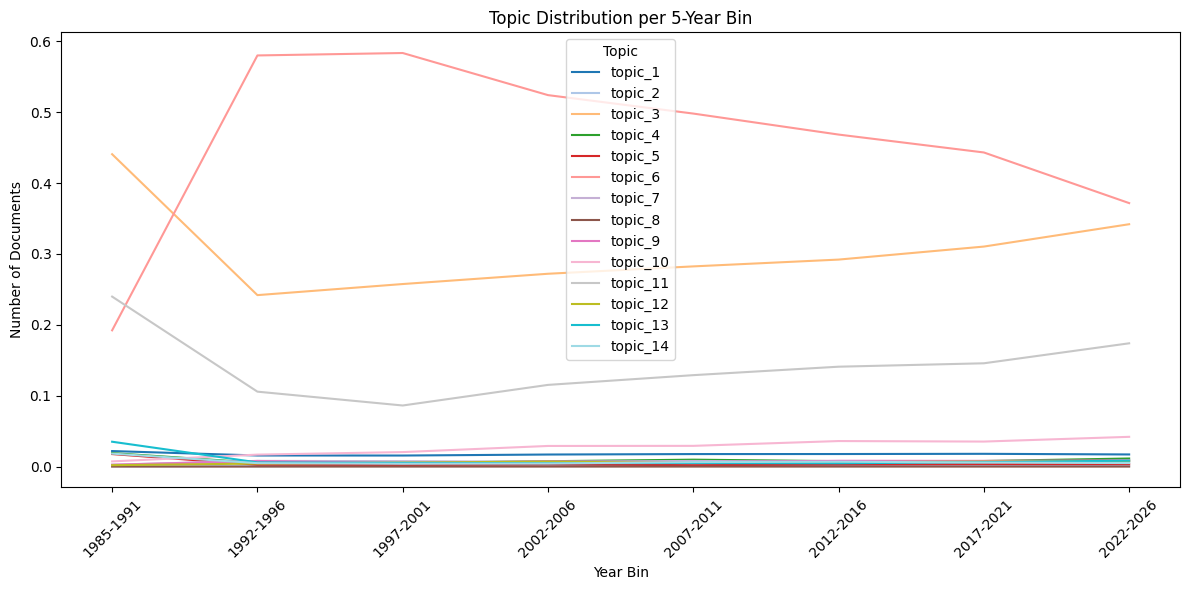

In [30]:
import matplotlib.pyplot as plt


df_topic_sum_by_bin.plot(x="year_bin", figsize=(12,6), colormap='tab20')

plt.xlabel('Year Bin')
plt.ylabel('Number of Documents')
plt.title('Topic Distribution per 5-Year Bin')
plt.legend(title='Topic')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [31]:
df_research = df[df['document_category'] == 'research']
df_research = df_research.reset_index(drop=True)

# Create 5-year bins based on 'year'
bins = list(range(df['year'].min(), df['year'].max() + 5, 5))
labels = [f"{b}-{b+4}" for b in bins[:-1]]  # e.g., "1990-1994"

df_research['year_bin'] = pd.cut(df_research['year'], bins=bins, labels=labels, right=False)
df_exploded = df_research.explode('topics')
topic_counts = df_exploded.groupby(['year_bin', 'topics']).size().reset_index(name='count')
topic_pivot = topic_counts.pivot(index='year_bin', columns='topics', values='count').fillna(0)

topics_to_plot = [2, 4, 8, 11]
#topics_to_plot = [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14]

topic_pivot[topics_to_plot].plot(figsize=(12,6), colormap='tab20')

plt.xlabel('Year Bin')
plt.ylabel('Number of Documents')
plt.title('Topic Distribution per 5-Year Bin')
plt.legend(title='Topic')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyError: 'topics'

In [ ]:
docs_per_bin = df_research.groupby('year_bin').size()
topic_pivot_norm = topic_pivot.div(docs_per_bin, axis=0)
topic_pivot_norm[topics_to_plot].plot(figsize=(12,6), colormap='tab20')

plt.xlabel('Year Bin')
plt.ylabel('Proportion of Documents')
plt.title('Normalized Topic Distribution per 5-Year Bin')
plt.legend(title='Topic')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Modeling a term over time ej creatnie supplementation.
See what percentage of articles are from the total on creatine supplementation
Normalization over time
Reviews redupliation what was on other papers. Limitations and discussion